---

# MISSING TIME SERIES DATA

---

>---
>
>Time Series data allows for methods for **fixing missing data** beyond `.fillna()`

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.DataFrame({'date':['2022-01-01', '2022-01-02', '2022-02-01', '2022-03-01', '2023-01-01', '2023-01-02'],
                   'sales':[10, 15, pd.NA, 20, 30, 35]})

# convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce', format='%Y-%m-%d')

# show results
print(df.info())
print('-'*75)

df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    6 non-null      datetime64[ns]
 1   sales   5 non-null      object        
dtypes: datetime64[ns](1), object(1)
memory usage: 228.0+ bytes
None
---------------------------------------------------------------------------


,date,sales
0,2022-01-01,10
1,2022-01-02,15
2,2022-02-01,<NA>
3,2022-03-01,20
4,2023-01-01,30
5,2023-01-02,35


In [3]:
# --------------------------------------------------------------------------------------------
# we need to set for newer versions of Pandas the following line of code in order to use 
pd.set_option('future.no_silent_downcasting', True)
# --------------------------------------------------------------------------------------------

<br><br>

---

## 1. Using `.ffill()` and `.bfill()` Methods

<br><br>

>---
>
>**Forward-Filling** and **Back-Filling** data replaces missing values with either the value from the previous available date, or the next available date.

In [4]:
# fill with forward value
df.ffill()

,date,sales
0,2022-01-01,10
1,2022-01-02,15
2,2022-02-01,15
3,2022-03-01,20
4,2023-01-01,30
5,2023-01-02,35


In [5]:
df.bfill()

,date,sales
0,2022-01-01,10
1,2022-01-02,15
2,2022-02-01,20
3,2022-03-01,20
4,2023-01-01,30
5,2023-01-02,35


<br><br>

---

## 2. Interpolating Missing Values

<br><br>

>---
>
>We can also **interpolate our data** as well. But to do this we need to convert that column into a `float`.
>
>This function is a `NumPy` special features.

In [6]:
df

,date,sales
0,2022-01-01,10
1,2022-01-02,15
2,2022-02-01,<NA>
3,2022-03-01,20
4,2023-01-01,30
5,2023-01-02,35


---

### 2.1. Using Function `pd.to_numeric()`



>---
>
>- The `pandas.to_numeric()` **function** safely converts a pandas `Series`, `1-D array`, or `list of values` into either a floating-point or integer numeric data type. It is the most robust way to clean dirty text columns that are supposed to contain numbers but were imported as generic `object/string` data types.
>
>- If the input is already of a numeric dtype, the dtype will be preserved. For `non-numeric inputs`, the default return dtype is `float64` or `int64` depending on the data supplied.
>
>- Use the `downcast parameter` to obtain other dtypes.

In [7]:
# Method No. 1
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df

,date,sales
0,2022-01-01,10.0
1,2022-01-02,15.0
2,2022-02-01,NaN
3,2022-03-01,20.0
4,2023-01-01,30.0
5,2023-01-02,35.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    6 non-null      datetime64[ns]
 1   sales   5 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 228.0 bytes


---

### 2.2. Using `.fillna()` Method

In [9]:
df = pd.DataFrame({'date':['2022-01-01', '2022-01-02', '2022-02-01', '2022-03-01', '2023-01-01', '2023-01-02'],
                   'sales':[10, 15, pd.NA, 20, 30, 35]})
# convert 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'], errors='coerce', format='%Y-%m-%d')

# Method No. 2
df['sales'] = df['sales'].fillna(np.nan).astype('float64')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    6 non-null      datetime64[ns]
 1   sales   5 non-null      float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 228.0 bytes


In [10]:
df

,date,sales
0,2022-01-01,10.0
1,2022-01-02,15.0
2,2022-02-01,NaN
3,2022-03-01,20.0
4,2023-01-01,30.0
5,2023-01-02,35.0


---

### 2.3. Time to use `.interpolate()`



>---
>
>**Interpolating** data replaces missing values with a linear approximation based on the values from the previous and next available dates.

In [11]:
df['sales'] = df['sales'].interpolate()
df

,date,sales
0,2022-01-01,10.0
1,2022-01-02,15.0
2,2022-02-01,17.5
3,2022-03-01,20.0
4,2023-01-01,30.0
5,2023-01-02,35.0


In [12]:
df

,date,sales
0,2022-01-01,10.0
1,2022-01-02,15.0
2,2022-02-01,17.5
3,2022-03-01,20.0
4,2023-01-01,30.0
5,2023-01-02,35.0


---

## LABORATORY

In [13]:
retail = pd.read_parquet('../Data/retail_2016_2017.parquet')
retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054944 entries, 0 to 1054943
Data columns (total 6 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   id           1054944 non-null  int64         
 1   date         1054944 non-null  datetime64[ns]
 2   store_nbr    1054944 non-null  int64         
 3   family       1054944 non-null  object        
 4   sales        1054944 non-null  float64       
 5   onpromotion  1054944 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 48.3+ MB


In [14]:
retail.head()

,id,date,store_nbr,family,sales,onpromotion
0,1945944,2016-01-01,1,AUTOMOTIVE,0.0,0
1,1945945,2016-01-01,1,BABY CARE,0.0,0
2,1945946,2016-01-01,1,BEAUTY,0.0,0
3,1945947,2016-01-01,1,BEVERAGES,0.0,0
4,1945948,2016-01-01,1,BOOKS,0.0,0


In [15]:
retail_agg = retail.groupby('date').agg({'sales':'sum'}).round().iloc[:10]
retail_agg

,sales
date,
2016-01-01,16433.0
2016-01-02,1066677.0
2016-01-03,1226736.0
2016-01-04,955957.0
2016-01-05,835320.0
2016-01-06,821686.0
2016-01-07,653504.0
2016-01-08,713608.0
2016-01-09,989209.0


In [16]:
# we'll create some missing values for the Laboratory
retail_agg.iloc[1] = np.nan
retail_agg.iloc[4:6] = np.nan

retail_agg

,sales
date,
2016-01-01,16433.0
2016-01-02,NaN
2016-01-03,1226736.0
2016-01-04,955957.0
2016-01-05,NaN
2016-01-06,NaN
2016-01-07,653504.0
2016-01-08,713608.0
2016-01-09,989209.0


<Axes: title={'center': 'Original DataFrame'}, xlabel='date'>

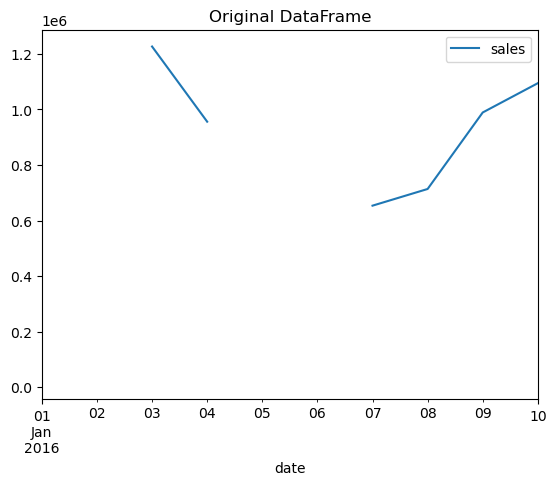

In [17]:
# let's see our DF
retail_agg.plot(
    title='Original DataFrame'
)

<Axes: title={'center': 'Filling Missing Values with the Mean'}, xlabel='date'>

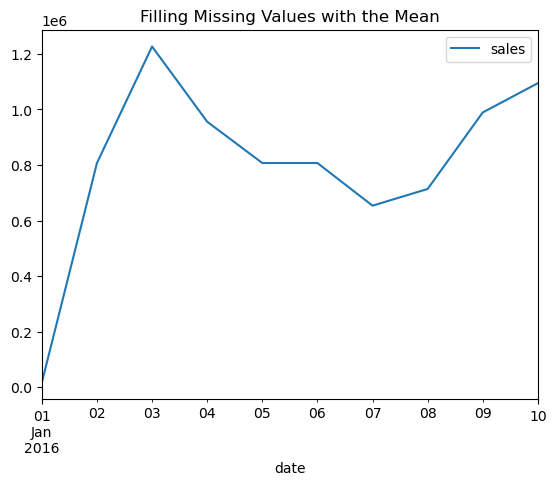

In [18]:
# filling missing values with the Mean
retail_agg.fillna(retail_agg.sales.mean()).plot(
    title='Filling Missing Values with the Mean'
)

<Axes: title={'center': 'Filling Missing Values with ".ffill()"'}, xlabel='date'>

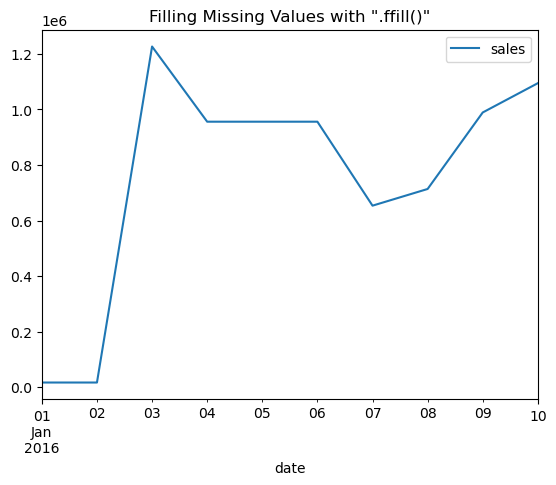

In [19]:
# filling missing values with 'ffill()'
retail_agg.ffill().plot(
    title='Filling Missing Values with ".ffill()"'
)

<Axes: title={'center': 'Filling Missing Values with ".bfill()"'}, xlabel='date'>

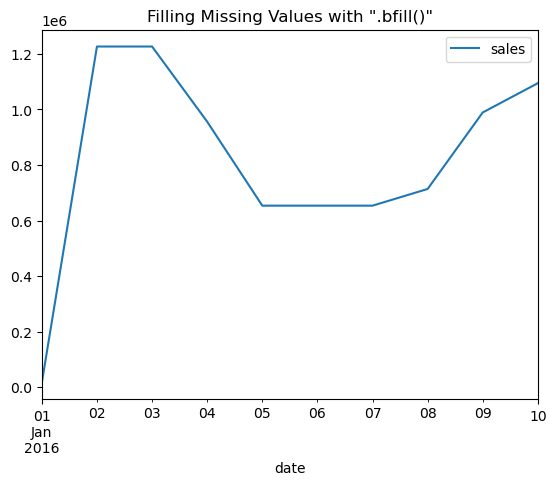

In [20]:
# filling missing values with 'bfill()'
retail_agg.bfill().plot(
    title='Filling Missing Values with ".bfill()"'
)

<Axes: title={'center': 'Filling Missing Values by Interpolating'}, xlabel='date'>

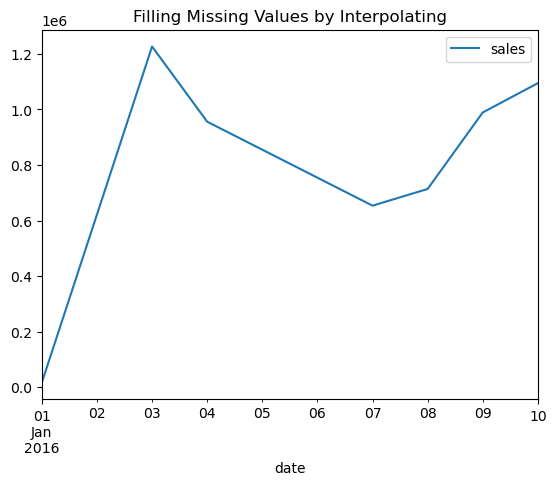

In [21]:
# filling missing values by Interpolation
retail_agg.interpolate().round().plot(
    title='Filling Missing Values by Interpolating'
)